In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
data = load_wine()
X = data.data
y = data.target

print("shape",X.shape)
print("class counts:", np.bincount(y))
print("wine class name:", data.target_names)

shape (178, 13)
class counts: [59 71 48]
wine class name: ['class_0' 'class_1' 'class_2']


In [4]:
X_train,X_test, y_train, y_test = train_test_split(X,y, random_state=42,test_size=0.2)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)


In [5]:
accuracy = accuracy_score(y_test,y_pred)
print("accuracy score: ", accuracy)

print("Macro averages")
print("Macro precision", precision_score(y_test,y_pred, average="macro"))
print("Macro recall", recall_score(y_test,y_pred, average="macro"))
print("Macro f1 score", f1_score(y_test,y_pred, average="macro"))

print("\n--- WEIGHTED AVERAGES ---")
print("Weighted Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Weighted Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("Weighted F1 Score :", f1_score(y_test, y_pred, average='weighted'))

accuracy score:  1.0
Macro averages
Macro precision 1.0
Macro recall 1.0
Macro f1 score 1.0

--- WEIGHTED AVERAGES ---
Weighted Precision: 1.0
Weighted Recall   : 1.0
Weighted F1 Score : 1.0


full classification report: 
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



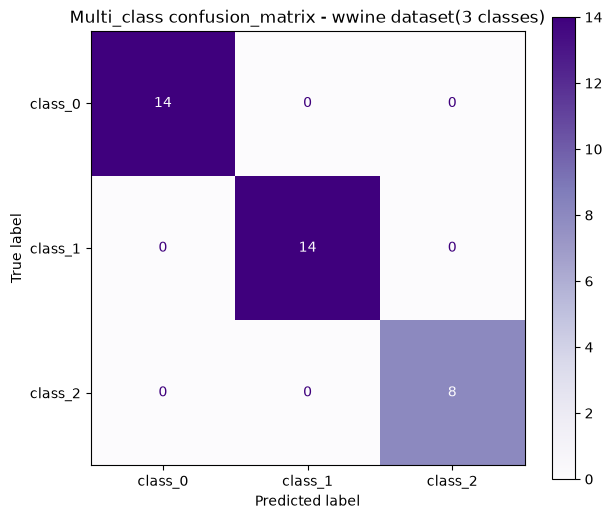

In [7]:
print("full classification report: ")
print(classification_report(y_test,y_pred, target_names=data.target_names))

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=data.target_names,
    cmap="Purples",
    ax = ax 
)
plt.title("Multi_class confusion_matrix - wwine dataset(3 classes)")
plt.show()

Overall Accuracy: 0.9740740740740741

--- MACRO vs WEIGHTED AVERAGES ---
Macro Precision   : 0.9743004763241677
Weighted Precision: 0.9746726063833693

Macro Recall      : 0.9733091626868717
Weighted Recall   : 0.9740740740740741

Macro F1 Score    : 0.9735158173590165
Weighted F1 Score : 0.9740879609991484

--- Full Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        51
           1       0.93      0.98      0.96        57
           2       0.96      1.00      0.98        55
           3       0.98      0.96      0.97        56
           4       1.00      0.94      0.97        51
           5       0.94      0.98      0.96        51
           6       1.00      0.98      0.99        55
           7       1.00      1.00      1.00        60
           8       0.94      0.92      0.93        50
           9       1.00      0.96      0.98        54

    accuracy                           0.97       540
   ma

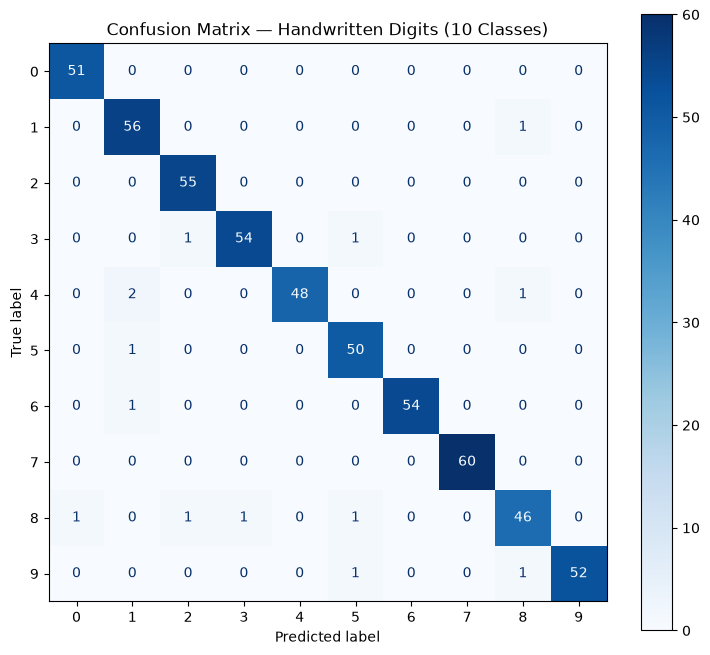

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 1. Digits Dataset Load karein (10 Classes: Numbers 0 se 9)
digits = load_digits()
X_dig = digits.data
y_dig = digits.target

# 2. Train-Test Split (70% Train, 30% Test — thoda kam train data taaki errors aayein)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dig, y_dig, test_size=0.3, random_state=10
)

# 3. Scaling
scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

# 4. Model Training (Max iter kam rakhi taaki thodi galtiyaan bachein)
model_digits = LogisticRegression(max_iter=200)
model_digits.fit(X_train_d_scaled, y_train_d)

# 5. Predict
y_pred_d = model_digits.predict(X_test_d_scaled)

# --- METRICS CALCULATIONS ---
print("Overall Accuracy:", accuracy_score(y_test_d, y_pred_d))

print("\n--- MACRO vs WEIGHTED AVERAGES ---")
print("Macro Precision   :", precision_score(y_test_d, y_pred_d, average='macro'))
print("Weighted Precision:", precision_score(y_test_d, y_pred_d, average='weighted'))

print("\nMacro Recall      :", recall_score(y_test_d, y_pred_d, average='macro'))
print("Weighted Recall   :", recall_score(y_test_d, y_pred_d, average='weighted'))

print("\nMacro F1 Score    :", f1_score(y_test_d, y_pred_d, average='macro'))
print("Weighted F1 Score :", f1_score(y_test_d, y_pred_d, average='weighted'))

# Full Classification Report
print("\n--- Full Classification Report ---")
print(classification_report(y_test_d, y_pred_d))

# Confusion Matrix Plot (10x10 Table)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_d,
    y_pred_d,
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix — Handwritten Digits (10 Classes)")
plt.show()